# Quantum Teleportation Circuit

Implementation of the 3-qubit quantum teleportation protocol using Qiskit.

---

## What is Quantum Teleportation?

Quantum teleportation transfers a qubit's quantum **state** from Alice to Bob using pre-shared entanglement and 2 classical bits — without the physical qubit ever travelling between them.

- It is **not** sci-fi teleportation. No matter moves. What moves is the *quantum state* (the amplitudes).
- Alice's original qubit is **destroyed** in the process (no-cloning theorem is respected).
- A classical communication channel is still required, so it cannot beat the speed of light.
- It is a core primitive for quantum networks, distributed quantum computing, and quantum error correction.

---

## Background

### Qubit superposition

A qubit lives in a superposition:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \quad |\alpha|^2 + |\beta|^2 = 1$$

Measuring collapses it to 0 or 1, destroying the superposition.

### Bell state (entanglement)

Two qubits can be **entangled**. The Bell state used here is:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Created by applying H to one qubit, then CNOT:

$$|00\rangle \xrightarrow{H \otimes I} \frac{|0\rangle+|1\rangle}{\sqrt{2}} \otimes |0\rangle \xrightarrow{\text{CNOT}} \frac{|00\rangle+|11\rangle}{\sqrt{2}}$$

---

## The Protocol

3 qubits:
- `q[0]` — Alice's message qubit, holds $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$
- `q[1]` — Alice's half of the Bell pair
- `q[2]` — Bob's half of the Bell pair (teleportation destination)

```
q[0]: ──[U(θ,φ)]──●──[H]──[M]────────────────────────
                   │              |
q[1]: ──[H]──●────⊕────────[M]───┼───────────────────
             │                   |         |
q[2]: ───────⊕──────────────[c_if X]──[c_if Z]──[|ψ⟩]
```

**Step 1** — Prepare the message: apply $U(\theta, \phi, 0)$ to `q[0]`.

**Step 2** — Create the Bell pair: H on `q[1]`, then CNOT(`q[1]` → `q[2]`).

**Step 3** — Alice's Bell measurement: CNOT(`q[0]` → `q[1]`), H(`q[0]`), then measure both. This **destroys** $|\psi\rangle$ on `q[0]`.

**Step 4** — Alice sends her 2 classical bits to Bob over a classical channel.

**Step 5** — Bob applies corrections:

| c[0] | c[1] | Bob's qubit before correction | Correction |
|------|------|-------------------------------|------------|
| 0    | 0    | $\alpha|0\rangle + \beta|1\rangle$ | none |
| 0    | 1    | $\alpha|1\rangle + \beta|0\rangle$ | X gate |
| 1    | 0    | $\alpha|0\rangle - \beta|1\rangle$ | Z gate |
| 1    | 1    | $\alpha|1\rangle - \beta|0\rangle$ | X then Z |

After corrections, `q[2]` is in state $|\psi\rangle$. Teleportation complete.

---

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram

try:
    from qiskit_aer import AerSimulator
    AER_AVAILABLE = True
    print("qiskit-aer loaded successfully.")
except ImportError:
    AER_AVAILABLE = False
    print("WARNING: qiskit-aer not found. Install with: pip install qiskit-aer")

# ── Parameters ──────────────────────────────────────────────────────────────
# State to teleport: |ψ⟩ = cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩
THETA = np.pi / 3   # 60°  — polar angle on Bloch sphere
PHI   = np.pi / 4   # 45°  — azimuthal angle on Bloch sphere
SHOTS = 4096

print(f"Teleporting: |ψ⟩ = cos({THETA/2:.3f})|0⟩ + e^(i·{PHI:.3f})·sin({THETA/2:.3f})|1⟩")
print(f"θ = {np.degrees(THETA):.1f}°,  φ = {np.degrees(PHI):.1f}°")

qiskit-aer loaded successfully.
Teleporting: |ψ⟩ = cos(0.524)|0⟩ + e^(i·0.785)·sin(0.524)|1⟩
θ = 60.0°,  φ = 45.0°


---

## 2. Prepare the Message Qubit

The universal single-qubit gate $U(\theta, \phi, \lambda)$ lets us place a qubit anywhere on the Bloch sphere:

$$U(\theta, \phi, \lambda) = \begin{pmatrix} \cos(\theta/2) & -e^{i\lambda}\sin(\theta/2) \\ e^{i\phi}\sin(\theta/2) & e^{i(\phi+\lambda)}\cos(\theta/2) \end{pmatrix}$$

We use $\lambda = 0$ so that $|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$.

Statevector amplitudes:
  α (|0⟩ coefficient): 0.8660+0.0000j
  β (|1⟩ coefficient): 0.3536+0.3536j
  |α|² + |β|²  = 1.000000  (must equal 1)


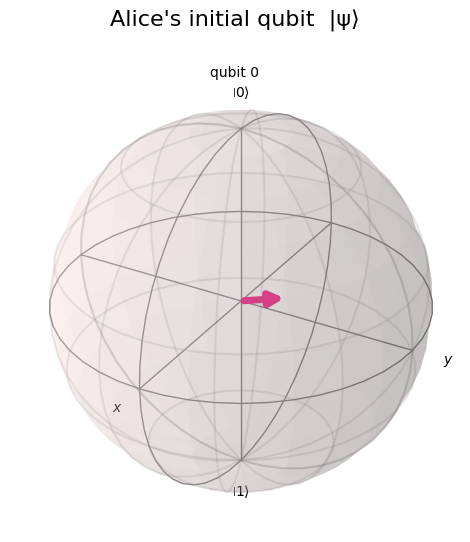

In [2]:
def get_message_statevector(theta, phi):
    """Return the statevector of the qubit prepared by U(theta, phi, 0)."""
    qc = QuantumCircuit(1)
    qc.u(theta, phi, 0, 0)
    return Statevector.from_label('0').evolve(qc)


sv = get_message_statevector(THETA, PHI)
print("Statevector amplitudes:")
print(f"  α (|0⟩ coefficient): {sv.data[0]:.4f}")
print(f"  β (|1⟩ coefficient): {sv.data[1]:.4f}")
print(f"  |α|² + |β|²  = {abs(sv.data[0])**2 + abs(sv.data[1])**2:.6f}  (must equal 1)")

fig = plot_bloch_multivector(sv, title="Alice's initial qubit  |ψ⟩")
fig

The point on the Bloch sphere above is exactly the state we will teleport to Bob.

---

## 3. Build the Teleportation Circuit

In [3]:
def build_teleportation_circuit(theta, phi):
    """
    Build the standard 3-qubit quantum teleportation circuit.

    Qubits
    ------
    q[0] : Alice's message qubit  (|ψ⟩ to teleport)
    q[1] : Alice's ancilla        (her half of the Bell pair)
    q[2] : Bob's qubit            (will receive |ψ⟩ after corrections)

    Classical bits
    --------------
    c[0] : Alice's measurement of q[0]  → controls Z correction on q[2]
    c[1] : Alice's measurement of q[1]  → controls X correction on q[2]
    """
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    circuit = QuantumCircuit(qr, cr)

    # Step 1 — Prepare the message qubit
    circuit.u(theta, phi, 0, qr[0])
    circuit.barrier(label='prepare')

    # Step 2 — Create Bell pair on q[1] and q[2]
    circuit.h(qr[1])
    circuit.cx(qr[1], qr[2])
    circuit.barrier(label='entangle')

    # Step 3 — Alice's Bell measurement
    circuit.cx(qr[0], qr[1])
    circuit.h(qr[0])
    circuit.barrier(label='Alice measures')
    circuit.measure(qr[0], cr[0])   # c[0] → Z correction
    circuit.measure(qr[1], cr[1])   # c[1] → X correction
    circuit.barrier(label='corrections')

    # Step 4 — Bob applies conditional corrections
    with circuit.if_test((cr[1], 1)):
        circuit.x(qr[2])
    with circuit.if_test((cr[0], 1)):
        circuit.z(qr[2])

    return circuit


circuit = build_teleportation_circuit(THETA, PHI)
print(f"Circuit depth : {circuit.depth()}")
print(f"Gate counts   : {dict(circuit.count_ops())}")
print()
print(circuit.draw('text', fold=100))

Circuit depth : 8
Gate counts   : {'barrier': 4, 'h': 2, 'cx': 2, 'measure': 2, 'if_else': 2, 'u': 1}

     ┌──────────────┐ prepare            entangle      ┌───┐ Alice measures ┌─┐    corrections »
q_0: ┤ U(π/3,π/4,0) ├────░──────────────────░───────■──┤ H ├───────░────────┤M├─────────░──────»
     └──────────────┘    ░    ┌───┐         ░     ┌─┴─┐└───┘       ░        └╥┘┌─┐      ░      »
q_1: ────────────────────░────┤ H ├──■──────░─────┤ X ├────────────░─────────╫─┤M├──────░──────»
                         ░    └───┘┌─┴─┐    ░     └───┘            ░         ║ └╥┘      ░      »
q_2: ────────────────────░─────────┤ X ├────░──────────────────────░─────────╫──╫───────░──────»
                         ░         └───┘    ░                      ░         ║  ║       ░      »
c: 3/════════════════════════════════════════════════════════════════════════╩══╩══════════════»
                                                                             0  1              »
«                       

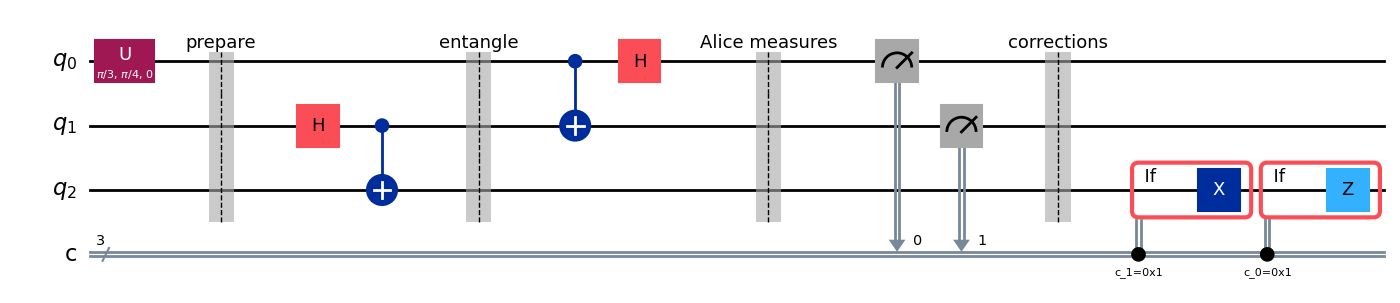

In [4]:
# Matplotlib circuit diagram
fig = circuit.draw('mpl', fold=80, style='iqp')
fig

---

## 4. Run the Simulation

In [5]:
def run_on_simulator(circuit, shots=SHOTS):
    """Transpile and run circuit on AerSimulator, return counts dict."""
    if not AER_AVAILABLE:
        raise RuntimeError("Install qiskit-aer: pip install qiskit-aer")
    simulator = AerSimulator()
    transpiled = transpile(circuit, simulator)
    job = simulator.run(transpiled, shots=shots)
    return job.result().get_counts()


print(f"Running teleportation circuit on AerSimulator ({SHOTS} shots)...")
main_counts = run_on_simulator(circuit)
print(f"Raw counts: {main_counts}")

Running teleportation circuit on AerSimulator (4096 shots)...
Raw counts: {'010': 978, '011': 1059, '001': 1058, '000': 1001}


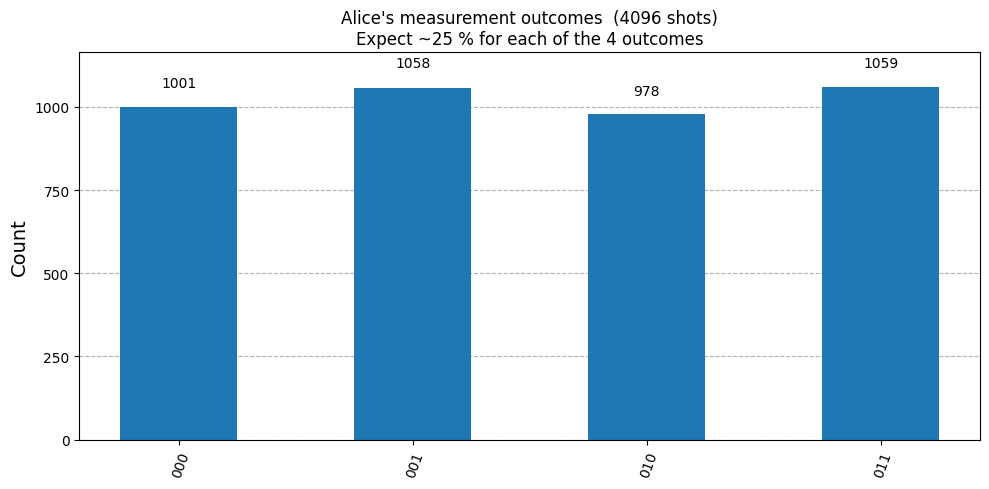

In [6]:
fig = plot_histogram(
    main_counts,
    title=f"Alice's measurement outcomes  ({SHOTS} shots)\nExpect ~25 % for each of the 4 outcomes",
    figsize=(10, 5)
)
fig

### Interpreting Alice's measurements

Qiskit bit strings are printed **right-to-left**: the rightmost character is `c[0]` and the second from the right is `c[1]`.

Each of the four outcomes `(c[0], c[1])` should appear with roughly **25 %** probability — this is a fundamental feature of the protocol, not a flaw. The randomness of Alice's result is expected; Bob's qubit ends up in $|\psi\rangle$ regardless of which outcome Alice gets.

In [7]:
corrections = {
    (0, 0): "no correction",
    (1, 0): "Z applied",
    (0, 1): "X applied",
    (1, 1): "X then Z applied",
}

total = sum(main_counts.values())
alice_dist = {}
for outcome_str, count in main_counts.items():
    bits = outcome_str.replace(' ', '')
    c0 = int(bits[-1])
    c1 = int(bits[-2]) if len(bits) >= 2 else 0
    key = (c0, c1)
    alice_dist[key] = alice_dist.get(key, 0) + count

print(f"Alice's measurement outcomes  ({total} shots):")
print(f"{'c[0]':>5}  {'c[1]':>5}  {'shots':>7}  {'%':>6}  correction")
print("-" * 50)
for (c0, c1), count in sorted(alice_dist.items()):
    pct = 100.0 * count / total
    label = corrections.get((c0, c1), "?")
    print(f"{c0:>5}  {c1:>5}  {count:>7}  {pct:>5.1f}%  {label}")

all_near_25 = all(abs(100.0 * c / total - 25.0) < 6.0 for c in alice_dist.values())
print()
if all_near_25:
    print("Distribution looks uniform (all outcomes within 6 % of 25 %).")
else:
    print("Distribution looks off — check the circuit.")

Alice's measurement outcomes  (4096 shots):
 c[0]   c[1]    shots       %  correction
--------------------------------------------------
    0      0     1001   24.4%  no correction
    0      1      978   23.9%  X applied
    1      0     1058   25.8%  Z applied
    1      1     1059   25.9%  X then Z applied

Distribution looks uniform (all outcomes within 6 % of 25 %).


---

## 5. Verification Circuit

To confirm that teleportation worked we need to check that Bob's qubit `q[2]` really is in state $|\psi\rangle$.

The trick: apply the **inverse gate** $U^\dagger(\theta, \phi, 0) = U(-\theta, 0, -\phi)$ to Bob's qubit **after** teleportation. If $q[2] = |\psi\rangle$ then $U^\dagger|\psi\rangle = |0\rangle$, so measuring `c[2]` should always give **0**.

Any `c[2] = 1` result is a teleportation failure.

In [8]:
def build_verification_circuit(theta, phi):
    """
    Same as the teleportation circuit but appends U†(theta, phi, 0) on q[2]
    and measures it into c[2].  If teleportation was perfect, c[2] = 0 always.
    """
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    circuit = QuantumCircuit(qr, cr)

    # Replicate the teleportation circuit
    circuit.u(theta, phi, 0, qr[0])
    circuit.barrier()
    circuit.h(qr[1])
    circuit.cx(qr[1], qr[2])
    circuit.barrier()
    circuit.cx(qr[0], qr[1])
    circuit.h(qr[0])
    circuit.barrier()
    circuit.measure(qr[0], cr[0])
    circuit.measure(qr[1], cr[1])
    circuit.barrier()
    with circuit.if_test((cr[1], 1)):
        circuit.x(qr[2])
    with circuit.if_test((cr[0], 1)):
        circuit.z(qr[2])
    circuit.barrier()

    # Verification: apply U†, measure q[2]
    circuit.u(-theta, 0, -phi, qr[2])   # U†(θ,φ,0) = U(-θ, 0, -φ)
    circuit.measure(qr[2], cr[2])

    return circuit


verification_circuit = build_verification_circuit(THETA, PHI)
print(circuit.draw('text', fold=100))

     ┌──────────────┐ prepare            entangle      ┌───┐ Alice measures ┌─┐    corrections »
q_0: ┤ U(π/3,π/4,0) ├────░──────────────────░───────■──┤ H ├───────░────────┤M├─────────░──────»
     └──────────────┘    ░    ┌───┐         ░     ┌─┴─┐└───┘       ░        └╥┘┌─┐      ░      »
q_1: ────────────────────░────┤ H ├──■──────░─────┤ X ├────────────░─────────╫─┤M├──────░──────»
                         ░    └───┘┌─┴─┐    ░     └───┘            ░         ║ └╥┘      ░      »
q_2: ────────────────────░─────────┤ X ├────░──────────────────────░─────────╫──╫───────░──────»
                         ░         └───┘    ░                      ░         ║  ║       ░      »
c: 3/════════════════════════════════════════════════════════════════════════╩══╩══════════════»
                                                                             0  1              »
«                                                         
«q_0: ────────────────────────────────────────────────────
«        

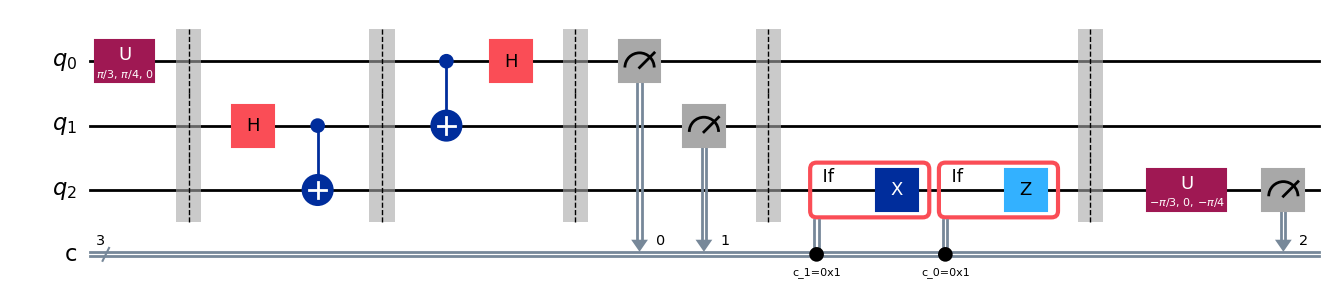

In [9]:
# Draw the verification circuit
fig = verification_circuit.draw('mpl', fold=80, style='iqp')
fig

In [10]:
print(f"Running verification circuit on AerSimulator ({SHOTS} shots)...")
verification_counts = run_on_simulator(verification_circuit)
print(f"Raw counts: {verification_counts}")

Running verification circuit on AerSimulator (4096 shots)...
Raw counts: {'000': 1037, '011': 987, '001': 1015, '010': 1057}


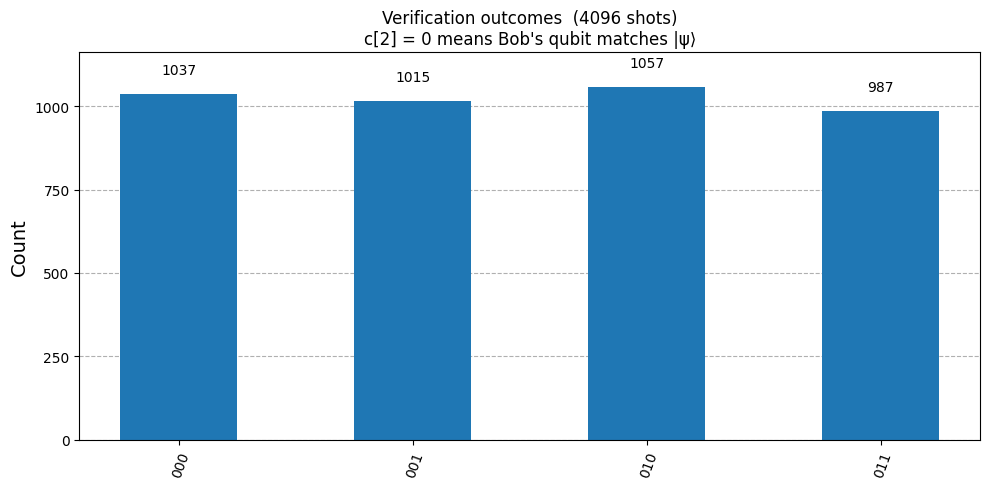

In [11]:
fig = plot_histogram(
    verification_counts,
    title=f"Verification outcomes  ({SHOTS} shots)\nc[2] = 0 means Bob's qubit matches |ψ⟩",
    figsize=(10, 5)
)
fig

In [12]:
total_v = sum(verification_counts.values())
# c[2] is the leftmost character in each Qiskit bit string
c2_zero = sum(v for k, v in verification_counts.items() if k.replace(' ', '')[0] == '0')
c2_one  = sum(v for k, v in verification_counts.items() if k.replace(' ', '')[0] == '1')

print(f"Verification results ({total_v} shots):")
print(f"  c[2] = 0 (success) : {c2_zero:>5}  ({100*c2_zero/total_v:.1f}%)")
print(f"  c[2] = 1 (failure) : {c2_one:>5}  ({100*c2_one/total_v:.1f}%)")
print()
if c2_one == 0:
    print("PASS — teleportation verified: c[2] = 0 in every shot.")
else:
    print(f"FAIL — {c2_one} shots had c[2]=1. Check the circuit.")

Verification results (4096 shots):
  c[2] = 0 (success) :  4096  (100.0%)
  c[2] = 1 (failure) :     0  (0.0%)

PASS — teleportation verified: c[2] = 0 in every shot.


---

## 6. Explore Different States

Change `theta` and `phi` below to teleport any qubit state you like.

In [13]:
interesting_states = {
    "|0⟩": (0, 0),
    "|1⟩": (np.pi, 0),
    "|+⟩ = (|0⟩+|1⟩)/√2": (np.pi / 2, 0),
    "|−⟩ = (|0⟩−|1⟩)/√2": (np.pi / 2, np.pi),
    "|i⟩ = (|0⟩+i|1⟩)/√2": (np.pi / 2, np.pi / 2),
    "Custom (60°, 45°)": (np.pi / 3, np.pi / 4),
}

results = []
for label, (theta, phi) in interesting_states.items():
    vc = build_verification_circuit(theta, phi)
    counts = run_on_simulator(vc, shots=2048)
    total_c = sum(counts.values())
    failures = sum(v for k, v in counts.items() if k.replace(' ', '')[0] == '1')
    pct_ok = 100 * (1 - failures / total_c)
    results.append((label, theta, phi, pct_ok))
    print(f"{label:35s}  θ={np.degrees(theta):6.1f}°  φ={np.degrees(phi):6.1f}°  success={pct_ok:.1f}%")

|0⟩                                  θ=   0.0°  φ=   0.0°  success=100.0%
|1⟩                                  θ= 180.0°  φ=   0.0°  success=100.0%
|+⟩ = (|0⟩+|1⟩)/√2                   θ=  90.0°  φ=   0.0°  success=100.0%
|−⟩ = (|0⟩−|1⟩)/√2                   θ=  90.0°  φ= 180.0°  success=100.0%
|i⟩ = (|0⟩+i|1⟩)/√2                  θ=  90.0°  φ=  90.0°  success=100.0%
Custom (60°, 45°)                    θ=  60.0°  φ=  45.0°  success=100.0%


All states should show **100 % success** on a noise-free simulator.

---

## 7. IBM Quantum Hardware (Optional)

On a real device you will see **3–8 % failure** on the verification qubit due to gate noise and decoherence — that is normal.

Requirements:
```bash
pip install qiskit-ibm-runtime
```
Then create a free account at [quantum.ibm.com](https://quantum.ibm.com) and save your API token once:
```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN')
```

In [14]:
# ── Uncomment and run this cell to submit to real IBM hardware ───────────────

# from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
#
# service  = QiskitRuntimeService()
# backend  = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# print(f"Using backend: {backend.name}")
#
# hw_circuit = transpile(circuit, backend=backend, optimization_level=3)
# sampler    = Sampler(mode=backend)
# job        = sampler.run([hw_circuit], shots=1024)
# print(f"Job ID: {job.job_id()}")
#
# hw_counts = job.result()[0].data.c.get_counts()
# print(hw_counts)
# plot_histogram(hw_counts, title="IBM Hardware — Alice's measurements")

print("IBM hardware block is commented out. Uncomment to run on a real device.")

IBM hardware block is commented out. Uncomment to run on a real device.


---

## Summary

| Step | Operation | Purpose |
|------|-----------|--------|
| 1 | `U(θ, φ, 0)` on `q[0]` | Prepare the quantum state to teleport |
| 2 | `H` + `CNOT` on `q[1]`, `q[2]` | Create a shared Bell pair (entanglement) |
| 3 | `CNOT` + `H` + measure `q[0]`, `q[1]` | Alice's Bell measurement — destroys original state |
| 4 | Classical channel | Alice sends 2 bits to Bob |
| 5 | Conditional `X` / `Z` on `q[2]` | Bob restores `|ψ⟩` on his qubit |
| ✓ | Apply `U†`, measure `q[2]` | Verification — `c[2]` must be 0 |

Key takeaways:
- **Entanglement** is the resource that makes teleportation possible.
- **2 classical bits** of communication are always required — no FTL loophole.
- The **no-cloning theorem** is respected: Alice's qubit is destroyed.
- Alice's 4 outcomes are equally likely (~25 % each) — genuinely random, by design.
- On a noise-free simulator the verification qubit is **always 0** (100 % fidelity).